In [1]:
# =============================================================================
# CHUNK 1 — LOAD DATA + SAMPLE + SELECT FEATURES + SCALE
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import pickle

sns.set(style="whitegrid")

# Load cleaned dataset
WineReview_A = pd.read_csv("data/WineReview_A_cleaned.csv")

# Random seed
Randomizer = 485
np.random.seed(Randomizer)

# 10,000-row sample
sample_size = min(10000, len(WineReview_A))
WineReview_A_sub = WineReview_A.sample(n=sample_size, random_state=Randomizer)

# DBSCAN features
dbscan_features = ["rating_points", "log_price", "price_per_point"]
dbscan_WineReview_A_sub = WineReview_A_sub[dbscan_features]

# Scaling
scaler = StandardScaler()
dbscan_scaled_sub = scaler.fit_transform(dbscan_WineReview_A_sub)

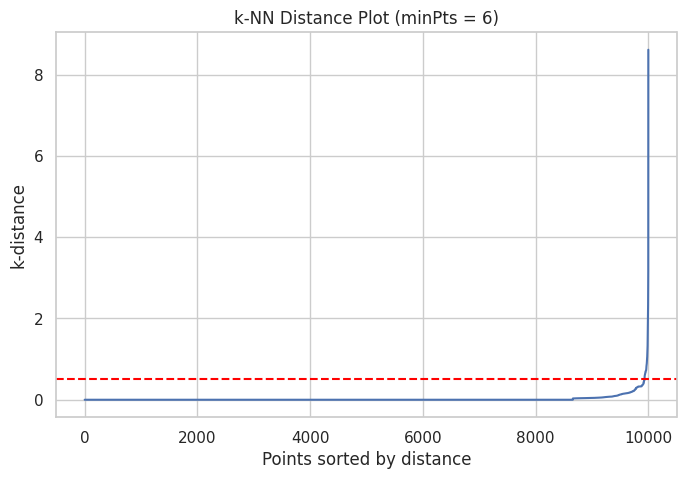

In [2]:
# =============================================================================
# CHUNK 2 — k-NN DISTANCE PLOT (EPS ELBOW)
# =============================================================================

minPts = 6  # rule of thumb: 2 × number of features

neighbors = NearestNeighbors(n_neighbors=minPts)
neighbors_fit = neighbors.fit(dbscan_scaled_sub)
distances, indices = neighbors_fit.kneighbors(dbscan_scaled_sub)

# Sort distances
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.axhline(y=0.5, color='red', linestyle='--')
plt.title("k-NN Distance Plot (minPts = 6)")
plt.xlabel("Points sorted by distance")
plt.ylabel("k-distance")
plt.show()

In [3]:
# =============================================================================
# CHUNK 3 — EPS GRID SEARCH
# =============================================================================

eps_grid = np.arange(0.05, 1.01, 0.05)

results = pd.DataFrame({
    "eps": eps_grid,
    "n_clusters": np.nan,
    "noise_pct": np.nan,
    "largest_cluster_pct": np.nan
})

minPts = 2 * dbscan_scaled_sub.shape[1]

for i, eps_val in enumerate(eps_grid):

    model = DBSCAN(eps=eps_val, min_samples=minPts).fit(dbscan_scaled_sub)
    labels = model.labels_

    non_noise = labels[labels != -1]

    if len(non_noise) == 0:
        n_clusters = 0
        largest_cluster_pct = 0
    else:
        n_clusters = len(np.unique(non_noise))
        largest_cluster_pct = (
            np.max(np.bincount(non_noise)) / len(dbscan_scaled_sub) * 100
        )

    noise_pct = np.mean(labels == -1) * 100

    results.loc[i, "n_clusters"] = n_clusters
    results.loc[i, "noise_pct"] = round(noise_pct, 2)
    results.loc[i, "largest_cluster_pct"] = round(largest_cluster_pct, 2)

results

,eps,n_clusters,noise_pct,largest_cluster_pct
0,0.05,346.0,8.59,3.19
1,0.10,133.0,5.15,10.78
2,0.15,64.0,3.57,12.66
3,0.20,34.0,2.10,12.94
4,0.25,29.0,1.57,12.97
5,0.30,28.0,1.40,12.97
6,0.35,3.0,0.75,99.09
7,0.40,2.0,0.65,99.29
8,0.45,2.0,0.60,99.34
9,0.50,2.0,0.56,99.38


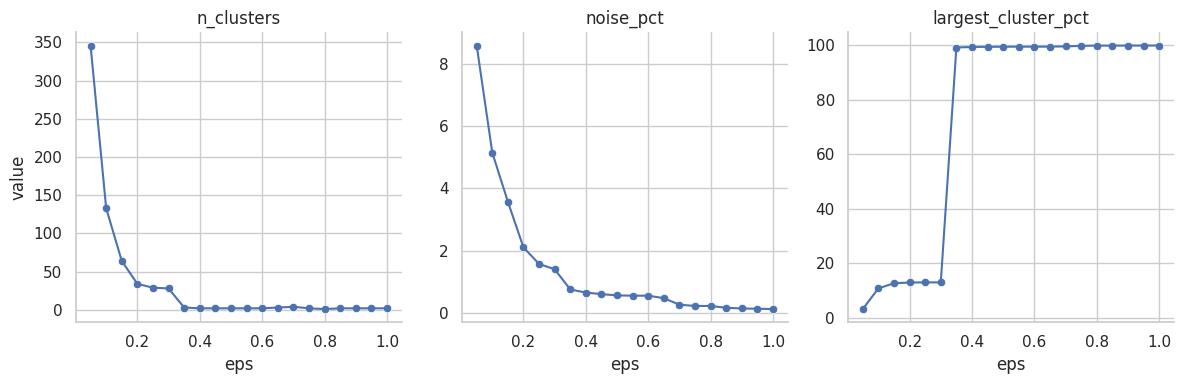

In [4]:
# =============================================================================
# CHUNK 4 — EPS METRICS VISUALIZATION
# =============================================================================

results_long = results.melt(
    id_vars="eps",
    value_vars=["n_clusters", "noise_pct", "largest_cluster_pct"],
    var_name="metric",
    value_name="value"
)

g = sns.FacetGrid(results_long, col="metric", sharey=False, height=4)
g.map_dataframe(sns.lineplot, x="eps", y="value")
g.map_dataframe(sns.scatterplot, x="eps", y="value")
g.set_titles("{col_name}")
g.set_axis_labels("eps", "value")
plt.show()

In [5]:
# =============================================================================
# CHUNK 5 — FINAL DBSCAN MODEL + CLUSTER TABLE
# =============================================================================

eps_candidate = 0.25
dbscan_model = DBSCAN(eps=eps_candidate, min_samples=minPts).fit(dbscan_scaled_sub)
labels = dbscan_model.labels_

unique, counts = np.unique(labels, return_counts=True)
cluster_table = pd.DataFrame({"cluster": unique, "count": counts})
cluster_table

,cluster,count
0,-1,157
1,0,915
2,1,1248
3,2,1204
4,3,1297
5,4,703
6,5,521
7,6,841
8,7,258
9,8,982


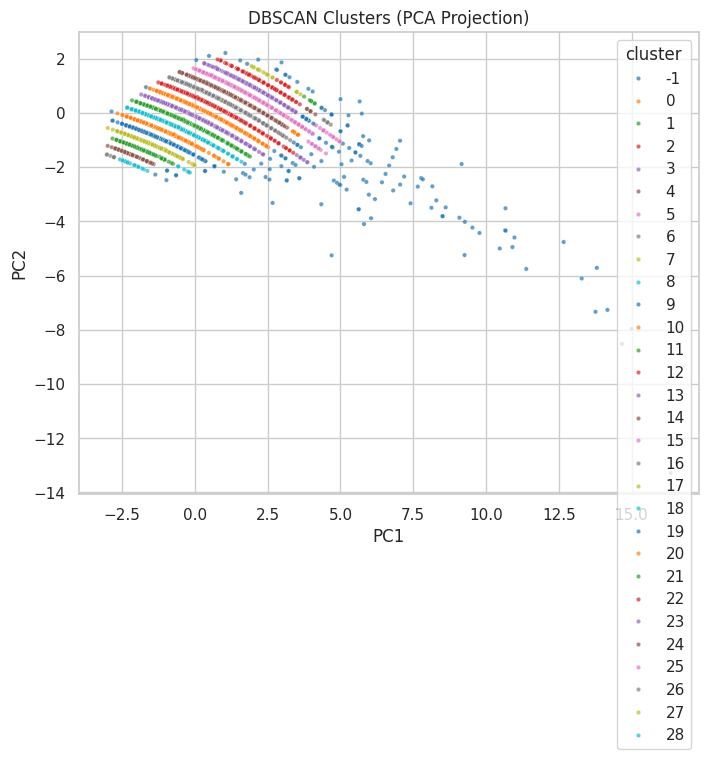

In [6]:
# =============================================================================
# CHUNK 6 — PCA VISUALIZATION
# =============================================================================

pca = PCA(n_components=2)
pcs = pca.fit_transform(dbscan_scaled_sub)

pc_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "cluster": labels
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pc_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=10,
    alpha=0.7
)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.show()

In [7]:
# =============================================================================
# CHUNK 7 — CLUSTER PROFILING (Cluster 7)
# =============================================================================

cluster_id = 7

WineReview_A_sub = WineReview_A_sub.copy()
WineReview_A_sub["cluster"] = labels

# Ensure price exists
if "price" not in WineReview_A_sub.columns or WineReview_A_sub["price"].isna().all():
    WineReview_A_sub["price"] = np.exp(WineReview_A_sub["log_price"])

# Vintage helper
WineReview_A_sub[".vintage"] = WineReview_A_sub.get("vintage", np.nan)

# ID helper
WineReview_A_sub[".id"] = WineReview_A_sub.get(".id", np.nan)

# Producer helper
WineReview_A_sub[".producer"] = (
    WineReview_A_sub["winery"]
    .astype(str)
    .fillna("unknown")
    .replace("nan", "unknown")
)

# Location helper
WineReview_A_sub[".location"] = (
    WineReview_A_sub["country"]
    .astype(str)
    .replace("nan", np.nan)
    .fillna(WineReview_A_sub["province"].astype(str).replace("nan", np.nan))
    .fillna("unknown")
)

if cluster_id not in WineReview_A_sub["cluster"].unique():
    print(f"Cluster {cluster_id} not found. Available clusters: {sorted(WineReview_A_sub['cluster'].unique())}")

else:
    df_c = WineReview_A_sub[WineReview_A_sub["cluster"] == cluster_id]

    summary7 = pd.DataFrame({
        "n": [len(df_c)],
        "pct_of_sample": [round(len(df_c) / len(WineReview_A_sub) * 100, 2)],
        "mean_rating": [round(df_c["rating_points"].mean(), 2)],
        "median_rating": [round(df_c["rating_points"].median(), 2)],
        "mean_price": [round(df_c["price"].mean(), 2)],
        "median_price": [round(df_c["price"].median(), 2)],
        "price_q25": [round(df_c["price"].quantile(0.25), 2)],
        "price_q75": [round(df_c["price"].quantile(0.75), 2)],
        "mean_price_per_point": [round(df_c["price_per_point"].mean(), 2)]
    })

    top_locations = (
        df_c[".location"]
        .value_counts()
        .reset_index()
        .rename(columns={"index": "location", ".location": "count"})
        .head(5)
    )

    top_producers = (
        df_c[".producer"]
        .value_counts()
        .reset_index()
        .rename(columns={"index": "producer", ".producer": "count"})
        .head(5)
    )

    reps = (
        df_c[[".id", ".producer", ".location", ".vintage",
              "rating_points", "price", "price_per_point"]]
        .sort_values(by=["rating_points", "price"], ascending=False)
        .head(8)
        .rename(columns={
            ".id": "wine_id",
            ".producer": "producer",
            ".location": "location",
            ".vintage": "vintage"
        })
    )

    print("\n=== Cluster Summary ===")
    print(summary7)

    print("\n=== Top Locations ===")
    print(top_locations)

    print("\n=== Top Producers ===")
    print(top_producers)

    print("\n=== Representative Wines ===")
    print(reps)


=== Cluster Summary ===
     n  pct_of_sample  mean_rating  median_rating  mean_price  median_price  \
0  258           2.58         83.0           83.0       17.93          15.0   

   price_q25  price_q75  mean_price_per_point  
0       11.0       22.0                  0.22  

=== Top Locations ===
       count  count
0         US    120
1      Spain     37
2      Chile     27
3  Argentina     25
4     France     23

=== Top Producers ===
               count  count
0  J. Garcia Carrion      2
1           EdenVale      2
2        Luigi Bosca      2
3             Siegel      2
4   Valentin Bianchi      2

=== Representative Wines ===
        wine_id                producer location  vintage  rating_points  \
70562       NaN         Laurent-Perrier   France      NaN             83   
109314      NaN           Jon Nathaniel       US      NaN             83   
8741        NaN  Pago de los Capellanes    Spain      NaN             83   
47717       NaN              W.H. Smith       US    

In [8]:
# =============================================================================
# CHUNK 8 — SAVE MODEL + SCALER
# =============================================================================

with open("models/dbscan_model.pkl", "wb") as f:
    pickle.dump(dbscan_model, f)

with open("models/dbscan_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("DBSCAN model + scaler saved to /models.")

DBSCAN model + scaler saved to /models.
